In [29]:
import pandas as pd

df = pd.read_csv("datasets/matches.csv")
df.head()


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


Goal:
Predict match winner based on teams and toss details


In [30]:
df.shape
df.columns
df.isnull().sum()


id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              0
umpire2              0
umpire3            577
dtype: int64

In [31]:
df = df.dropna(subset=['winner'])


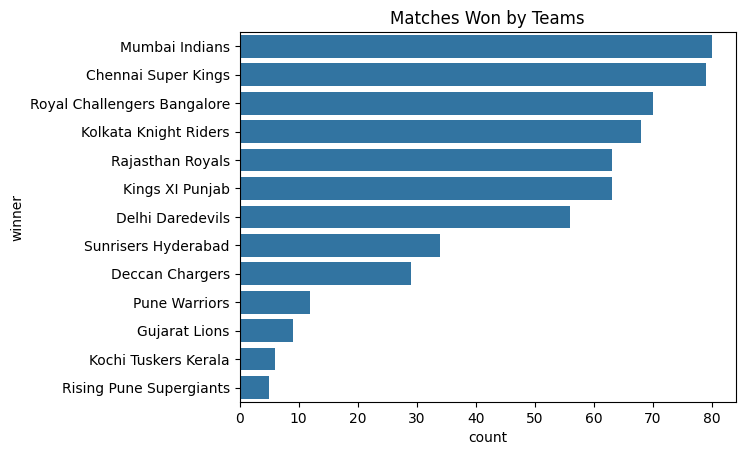

<Figure size 640x480 with 0 Axes>

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y='winner', data=df, order=df['winner'].value_counts().index)
plt.title("Matches Won by Teams")
plt.show()

plt.savefig("visualizations/team_wins.png", dpi=300, bbox_inches='tight')


In [33]:
toss_win = (df['toss_winner'] == df['winner']).mean()
print("Toss winner win %:", toss_win)


Toss winner win %: 0.5069686411149826


In [34]:
X = df[['team1','team2','toss_winner','toss_decision','venue']]
y = df['winner']


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [36]:
import pandas as pd

# 1) Features + Target
X = df[['team1','team2','toss_winner','toss_decision','venue']].copy()
y = df['winner'].copy()

# 2) Missing winners remove (safety)
mask = y.notna()
X = X[mask]
y = y[mask]

# 3) One-hot encode features (IMPORTANT)
X = pd.get_dummies(X, columns=['team1','team2','toss_winner','toss_decision','venue'], drop_first=True)

# 4) Confirm: ab koi object column nahi hona chahiye
print(X.dtypes.value_counts())


bool    71
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.43478260869565216


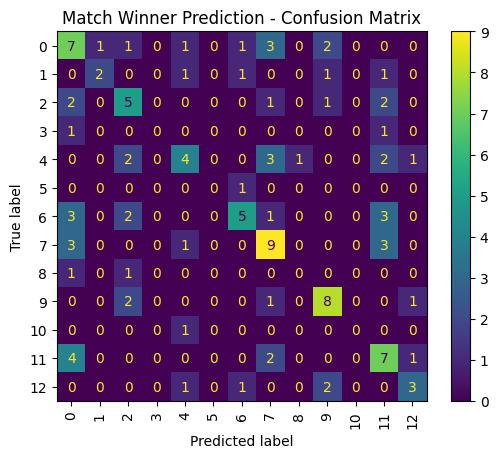

<Figure size 640x480 with 0 Axes>

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

ConfusionMatrixDisplay(cm).plot(xticks_rotation=90)
plt.title("Match Winner Prediction - Confusion Matrix")
plt.show()

plt.savefig("visualizations/confusion_matrix.png", dpi=300, bbox_inches='tight')


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))


                             precision    recall  f1-score   support

        Chennai Super Kings       0.33      0.44      0.38        16
            Deccan Chargers       0.67      0.33      0.44         6
           Delhi Daredevils       0.38      0.45      0.42        11
              Gujarat Lions       0.00      0.00      0.00         2
            Kings XI Punjab       0.44      0.31      0.36        13
       Kochi Tuskers Kerala       0.00      0.00      0.00         1
      Kolkata Knight Riders       0.56      0.36      0.43        14
             Mumbai Indians       0.45      0.56      0.50        16
              Pune Warriors       0.00      0.00      0.00         2
           Rajasthan Royals       0.57      0.67      0.62        12
    Rising Pune Supergiants       0.00      0.00      0.00         1
Royal Challengers Bangalore       0.37      0.50      0.42        14
        Sunrisers Hyderabad       0.50      0.43      0.46         7

                   accuracy     

c:\Users\deenu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\deenu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\deenu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

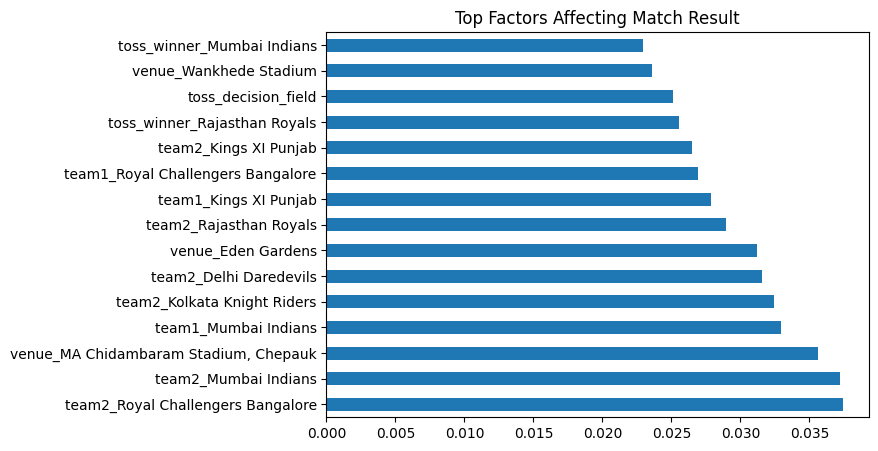

<Figure size 640x480 with 0 Axes>

In [40]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)

top_features.plot(kind='barh', figsize=(7,5))
plt.title("Top Factors Affecting Match Result")
plt.show()

plt.savefig("visualizations/feature_importance.png", dpi=300, bbox_inches='tight')


Key Findings:
- Match outcome highly unpredictable (low model accuracy)
- Toss winner has noticeable impact
- Some teams perform consistently better
- Venue affects match result

Sports Insight:
Cricket matches depend heavily on situational factors, not only team strength.

Recommendation:
Teams should analyze venue performance and toss strategy before match.
